# A Monte Carlo of NBA Shot Sequences Testing the "Heating Up" Phenomenon.

In [7]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from src.simulations import monte_carlo_simulation, calculate_simulated_streaks, create_df
from src.player_data import clean_data, calculate_metrics
from src.comparisons import fgp_p_value, streak_percentiles
from src.graphs import fgp_histogram, consecutive_makes_bar

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Introduction
The idea of "heating up" typically refers to a player's ability to make shots increasing after making multiple consecutive shots. This leaves an interesting statistical question: Does a player actually "heat up"? Or do shot streaks tend to fall within statistical reason. In this project, we will examine Luka Doncic's shot sequence during the 2023-2024 NBA season, and will compare that to a simulation where each shot is independent with a constant probability. For hthe purpose of this project, "heating up" will be determined using jump shot field goal percentage after making three consecutive shots, and max streak of makes.

## Null and Alternate Hypothesis
The null hypothesis moving forward is the following: The observed shot sequence for Luka Doncic in the 2023-2024 NBA season is consistent with a model in which each shot is independent with a constant probability equalling the field goal percentage of Luka Doncic during the 2023-2024 NBA season.

The alternate hypothesis moving forward is the following: The observed shot sequence for Luka Doncic in the 2023-2024 NBA season is NOT consistent with a model in which each shot is independent with a constant probability equalling the field goal percentage of Luka Doncic during the 2023-2024 NBA season.

For this project, the significance level is: α = 0.05

## Data Overview
The data used in this project was provided via a dataset on Kaggle, and contains the shot sequence for Luka Doncic during the 2023-2024 NBA season, ordered by when the shot was taken. To restrict the dataset to strictly jump shots, any layups, dunks, and floaters are removed from the dataset before being used. After filtering the dataset, 1006 jump shots are left for analysis.

In [8]:
real_shot_data = clean_data()
real_data, real_fg_after_3, longest_real_streak, real_fga_after_three, real_fgm_after_three = calculate_metrics(data=real_shot_data)

The calculate_metrics function contains the following metrics: field goal percentage after three consecutive jump shot makes, longest streak of makes, field goal attempts after three conecutive jump shot makes, and field goals made after three consecutive jump shot makes. Note that field goal percentage, attempts, and makes are only jump shot statistics.

## Methodology
Luka Doncic's real jump shot statistics were calculated by tracking previously made consecutive shots made before the current shot. If the shot is made a streak counter integer variable is incremented, and if it missed the streak counter variable is added to a list  of streaks, before setting the streak counter variable equal to 0. Before recording each shot, if the current streak is greater than or equal to three, a variable keeping track of field goals attempted after three consecutive makes and a variable keeping track of field goals made after three consecutive makes are updated accordingly.

A consecutive streak of three shots was chosen to keep track of because it provides a larger sample size while maintaining the idea of "heating up" occuring after multiple shot makes.

The Monte Carlo simulation works by taking the field goal of the cleaned up dataset, and using that in an RNG model to simulate 10000 seasons, where 1006 shots are attempted each (equalling the 2023-2024 season). It is important to note the following assumptions made in the Monte Carlo simulation: Luka Doncic takes exactly as many shots as in the 2023-2024 season, conditions are equivalent to the 2023-2024 seasons (opposing teams, current teammates, etc.), and Luka Doncic's health is the same as the 2023-2024 season.


## Exploratory Analysis
The FG%, total attempts, longest streak, and FG% after three makes are presented below.

In [ ]:
fga = len(real_data)
fgm = real_data["SHOT_MADE"].sum()
fgp = fgm / fga

print(f"FG% = {round(fgp*100, 2)}%")
print(f"Total Number of Opportunities: {fga}")
print(f"Longest Real Streak: {longest_real_streak.item()}")
print(f"Real FG% After At Least Three Makes: {round(real_fg_after_3, 2)}")

FG% = 39.86%
Total Number of Opportunities: 1006
Longest Real Streak: 8.0
Real FG% After Three Makes: 0.42


## Monte Carlo
In this Monte Carlo simulation, 10,000 hypothetical seasons are simulated. Each simulation contains the same number of jump shots Luka Doncic took during the 2023-2024 NBA season. Each shot is assumed to be independent with a constant probability equal to his observed field goal percentage. Game context, defensive adjustments, shot difficulty, and other factors that may affect shot result are not modeled.

In [10]:
n = 10000
seed = 42

simulation = monte_carlo_simulation(n=n, seed=seed, fga=fga, fgperc=fgp)
longest_simulated_streaks, simulated_fgp_after_three = calculate_simulated_streaks(simulation=simulation)
df = create_df(simulation=simulation, longest_streaks=longest_simulated_streaks, fgp_after_3=simulated_fgp_after_three)

## Results

In [ ]:
pvalue = fgp_p_value(simulated_fg=df, real_fg=real_fg_after_3, n=n)
percentile = streak_percentiles(df=df, longest_real_streak=longest_real_streak)

print(f"Real FG% After At Least Three Consecutive Makes: {round(real_fg_after_3 * 100, 2)}%")
print(f"Simulated FG% After At Least Three Consecutive Makes: {round(np.average(simulated_fgp_after_three) * 100, 2)}%")
print(f"P-value for FG% After At Least Three Consecutive Makes: {pvalue}")
print(f"Real Streak Percentile: {round(percentile.iloc[-1] * 100, 0)}")


Real FG% After Three Consecutive Makes: 42.19%
Simulated FG% After Three Consecutive Makes: 39.34%
P-value for FG% After Three Consecutive Makes: 0.3388661133886611
Real Streak Percentile: 77.0


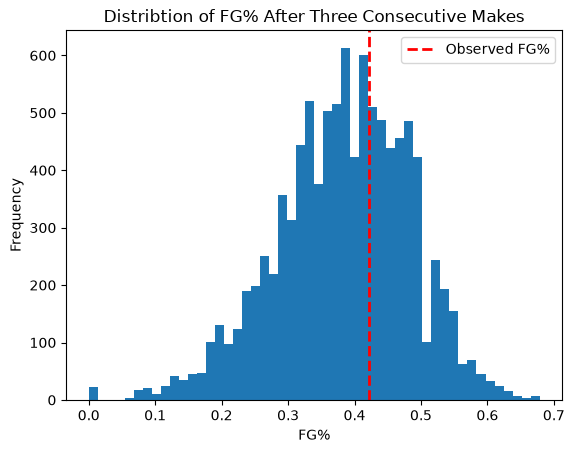

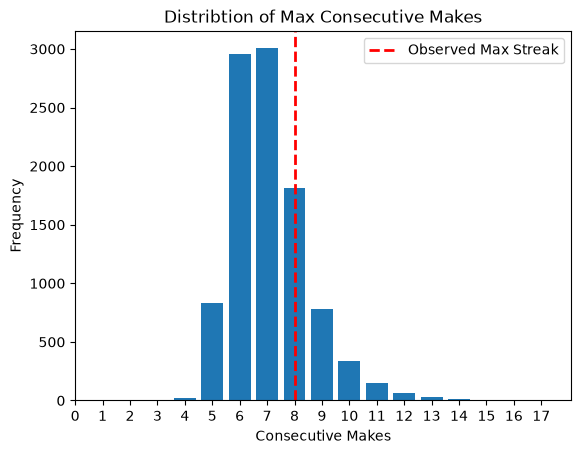

In [14]:
fgp_histogram(real_fg_after_3=real_fg_after_3, simulated_fg_after_3=simulated_fgp_after_three)
consecutive_makes_bar(simulated_consecutive_makes=longest_simulated_streaks, real_consecutive_makes=longest_real_streak)

## Discussion
The p-value estimated from the simulation is approximately to be 0.34, which is above the significance level of 0.05, thus we fail to reject the null hypothesis. Luka Doncic's observed field goal percentage after at least three makes was approximately 42.19%, compared to an average of 39.34% in the simulated seasons. Although his observed field goal percentage was higher, the results suggest this difference is not statistically unusual under an independent model in which each shot has a constant probability.

Luka Doncic's longest observed streak also fell in the 77th percentile of the simulated longest streaks. While this means a longer streak was observed than most simulated streaks, it is not extreme enough to be considered unusual under the independent model.

It is important to recognize the aforementioned assumptions and how they could affect the simulated stats. In a real NBA game, once a player makes multiple shots in a row, individual defenders will play tougher defense, and defensive schemes may be placed to stop that player, which could result in lower observed stats than simulated stats. It is also important to recognize the effect of time-based events, such as games ending, timeouts, free throws, quarter endings, and any other events that may throw off the pace of the game. 